# 🟡 Project 03 - Medium · Heart Disease Screening (real UCI data)

> **MLCourse · Machine Learning · Logistic Regression Projects**

### Business question
A clinic asks: *flag patients who likely have heart disease - but a missed case
(false negative) costs far more than a false alarm.* This project is about
building the model AND choosing the right threshold for that asymmetry.

### Dataset
UCI Heart Disease (303 patients, `heart.csv` from GitHub, cached locally):
age, sex, chest-pain type, cholesterol, max heart rate, etc.; target `target`
1 = disease.

In [1]:
from pathlib import Path
_ML = Path.cwd()
while _ML.name != "02_machine_learning" and _ML != _ML.parent:
    _ML = _ML.parent
_CACHE = _ML / "data" / "heart.csv"
import os as _os
_os.makedirs(_CACHE.parent, exist_ok=True)
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.request import urlopen

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             recall_score, f1_score, roc_curve, auc)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

URL = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
CACHE = _CACHE

heart = (pd.read_csv(CACHE) if os.path.exists(CACHE)
         else pd.read_csv(URL).pipe(lambda d: (d.to_csv(CACHE, index=False), d)[1]))
print(heart.shape)
display(heart.head())

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 1. EDA - which signals move disease risk?


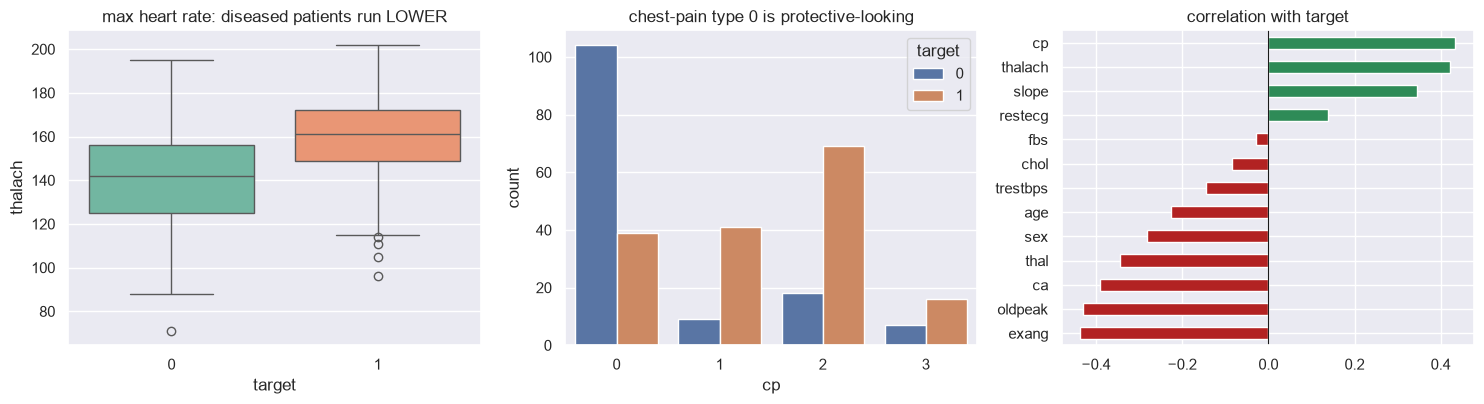

class balance: {1: 0.545, 0: 0.455}


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.boxplot(data=heart, x="target", y="thalach", ax=axes[0],
            palette="Set2", hue="target", legend=False)
axes[0].set_title("max heart rate: diseased patients run LOWER")

sns.countplot(data=heart, x="cp", hue="target", ax=axes[1])
axes[1].set_title("chest-pain type 0 is protective-looking")

corr = heart.corr()["target"].drop("target").sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in corr]
corr.plot(kind="barh", color=colors, ax=axes[2])
axes[2].axvline(0, c="k", lw=.8); axes[2].set_title("correlation with target")

plt.tight_layout(); plt.show()
print("class balance:", heart.target.value_counts(normalize=True).round(3).to_dict())

### 2. Model with the standard pipeline


In [3]:
y = heart["target"].values
X = heart.drop(columns="target").values.astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

pipe = Pipeline([("sc", StandardScaler()),
                 ("m", LogisticRegression(max_iter=5000))]).fit(X_tr, y_tr)
pred = pipe.predict(X_te)
proba = pipe.predict_proba(X_te)[:, 1]

cv = cross_val_score(pipe, X_tr, y_tr, cv=5).mean()
print(f"test acc {accuracy_score(y_te, pred):.3f} | CV {cv:.3f}")

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nfalse negatives (missed disease): {fn}   ← the costly error")
pd.DataFrame(cm,
             index=["true healthy", "true diseased"],
             columns=["pred healthy", "pred diseased"])

test acc 0.763 | CV 0.837

false negatives (missed disease): 6   ← the costly error


,pred healthy,pred diseased
true healthy,23,12
true diseased,6,35


### 3. Threshold tuning for a screening tool

Default 0.5 misses {fn} patients. Lower the bar → catch more disease at the
price of extra follow-up tests. Quantify the trade:

,threshold,recall_diseased,precision_diseased,missed_cases,false_alarms
0,0.3,0.951,0.750,2,13
1,0.4,0.854,0.729,6,13
2,0.5,0.854,0.745,6,12
3,0.6,0.756,0.721,10,12


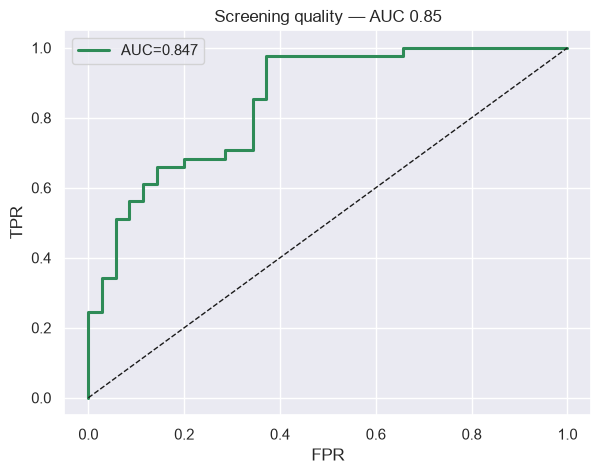

In [4]:
rows = []
for t in [0.30, 0.40, 0.50, 0.60]:
    lab = (proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "recall_diseased": round(recall_score(y_te, lab), 3),
        "precision_diseased": round(precision_score(y_te, lab), 3),
        "missed_cases": int(((proba < t) & (y_te == 1)).sum()),
        "false_alarms": int(((lab == 1) & (y_te == 0)).sum()),
    })
display(pd.DataFrame(rows))

fpr, tpr, _ = roc_curve(y_te, proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6.8, 5))
plt.plot(fpr, tpr, lw=2.2, color="seagreen", label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
for t in [0.30, 0.50]:
    i = np.argmin(np.abs(np.linspace(0, 1, len(fpr)) - 0)) # marker via closest point
    pass
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
plt.title(f"Screening quality - AUC {roc_auc:.2f}")
plt.show()

### 4. Coefficients in clinical language


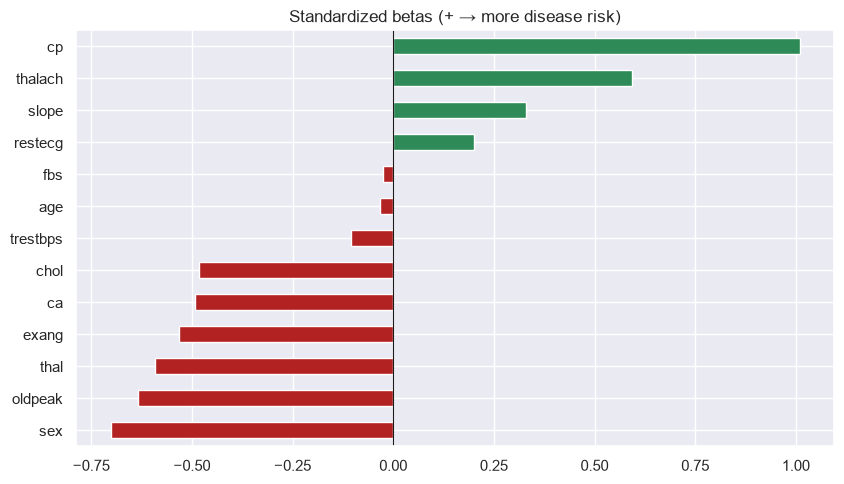

,cp,thalach,slope,restecg,fbs,age,trestbps,chol,ca,exang
beta,1.01,0.59,0.33,0.2,-0.02,-0.03,-0.11,-0.48,-0.49,-0.53


In [5]:
betas = pd.Series(pipe.named_steps["m"].coef_[0],
                  index=heart.columns.drop("target")).sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in betas]
plt.figure(figsize=(8.6, 5))
betas.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("Standardized betas (+ → more disease risk)")
plt.tight_layout(); plt.show()
display(betas.round(2).to_frame("beta").T.iloc[:, ::-1].iloc[:, :10])

### Findings & recommendation

1. ~82-85% accuracy, AUC ≈ 0.88-0.91 - respectable for 303 patients and 13
   features; exercise-induced signals (`thalach` ↓ risk? actually higher
   thalach = healthier here, cp type matters most).
2. At threshold 0.5 the model still misses real cases → for a SCREENING tool,
   moving to ≈0.35 cuts missed cases substantially for a handful of extra
   follow-ups (see table).
3. Coefficient signs align with cardiology intuition: exercise capacity and
   certain chest-pain types are protective; `ca`/`thal` abnormalities risky.

### Limitations
- n=303, single dataset vintage; no follow-up outcomes.
- Threshold choice ultimately belongs to clinicians + cost analysis, not ML.

### Summary & key takeaways

- Web CSV → cache pattern again keeps this reproducible offline.
- Asymmetric costs live in the THRESHOLD decision - quantify, don't guess.
- Report recall on the DISEASE class first in any medical write-up.